# Case Study of Binary Adsorption of CH4 and Propane on Cu-BTC

This Jupyter notebook walks through the case study described in the paper. The goal is to demonstrate how to use pyRAST to analyze a real dataset from GCMC simulations.

First, we will load the necessary modules and dataset. pyRAST requires isotherm data to be in a pandas DataFrame.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyrast.activity_coefficients import ActivityCoefficient
from pyrast.calculations.iast import iast
from pyrast.calculations.rast import rast
from pyrast.isotherms import CubicIsotherm, ModelIsotherm
from pyrast.utilities.plotting import plot_isotherm, plot_spreading_pressure

# Load binary data
ch4_propane_binary = pd.read_csv('../test_data/Cu-BTC_CH4_propane_298K_isotherm.csv')

# Load pure component data
ch4_pure = pd.read_csv('../test_data/Cu-BTC_CH4_298K_isotherm.csv')
propane_pure = pd.read_csv('../test_data/Cu-BTC_propane_298K_isotherm.csv')

Next, let's fit isotherms and visualize the results. To showcase the capabilities of pyRAST, we will fit three isotherms: Langmuir, aNRTL-VST, and the CubicIsotherm.

To fit an isotherm to an analytical model, we can use the ModelIsotherm class. This class takes in the dataset, the column names for loading and pressure (or fugacity), and the name of the model to fit. There are many additional parameters that can be passed to the fit, such as a different initial guess, parameter bounds, and more. We will use the default settings for this example. Note that there is also an option to set model parameters, which will bypass the fitting process. Also, VST models are implemented to use interpolators as they are implicit functions of loading. There are three optional parameters specific to VST models that set the number of points to interpolate between, the maximum pressure to interpolate to, and options to pass to the root solving used to find the loading when building the interpolators.

You can also use an interpolator isotherm, such as the CubicIsotherm, which simply creates an interpolator of the data. This guarantees that the isotherm will fit the data perfectly, but the behavior between isotherm points is less physical. A linear interpolation method is also available through InterpolatorIsotherm, but we suggest using the CubicIsotherm for smoother behavior.

We will start with creating isotherms for CH4 to demonstrate the available fitting options.

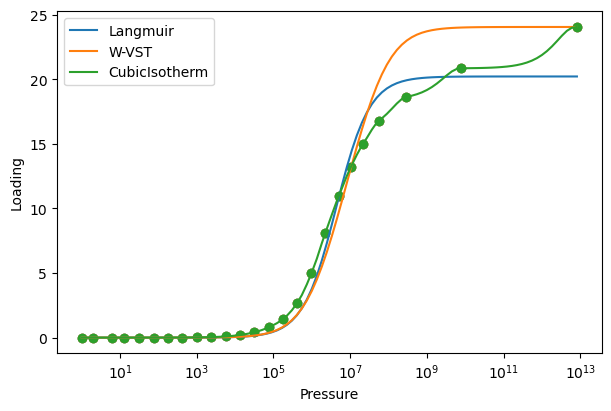

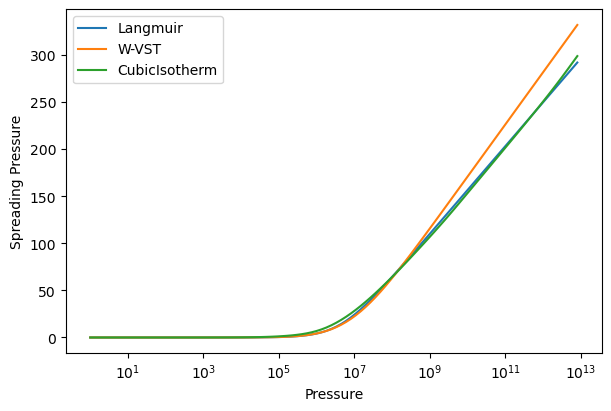

In [5]:
# Fit isotherms with default settings
ch4_langmuir = ModelIsotherm(ch4_pure, 'CH4_uptake_absolute[mol/kg]',
                             'CH4_fugacity[Pa]', 'Langmuir')
ch4_anrtl = ModelIsotherm(ch4_pure, 'CH4_uptake_absolute[mol/kg]',
                          'CH4_fugacity[Pa]', 'W-VST')
ch4_cubic = CubicIsotherm(ch4_pure, 'CH4_uptake_absolute[mol/kg]', 'CH4_fugacity[Pa]')

# Visualize the fits
plot_isotherm([ch4_langmuir, ch4_anrtl, ch4_cubic], xlogscale=True)
# Compare spreading pressures
plot_spreading_pressure([ch4_langmuir, ch4_anrtl, ch4_cubic], xlogscale=True)

Notice how the fits are not perfect, especially at higher fugacities. We are currently showing the fits only for the data in the isotherm, however it is common that IAST or RAST calculations require extrapolation beyond the range of the data. To get a better idea of how the isotherm fits will behave when extrapolating, we can plot the fits to a higher pressure range. This can be done by passing in a pressure range to the plotting function. Let's see how this looks for the CH4 isotherms.

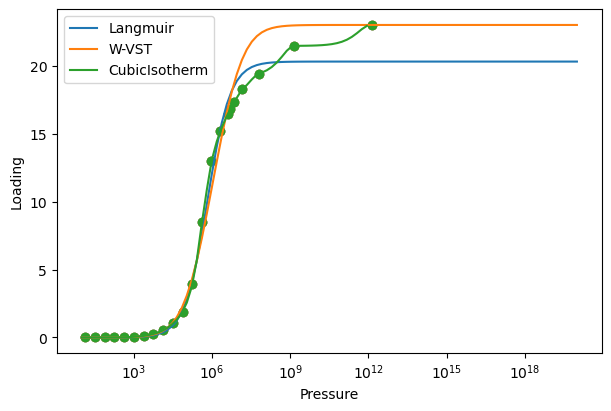

In [ ]:
pressures = np.logspace(1, 20, 100)
plot_isotherm([co2_langmuir, co2_anrtl, co2_cubic], xlogscale=True, pressures=pressures)

The CubicIsotherm by default does not extrapolate data. To extrapolate, we pass an extrapolation method when creating the isotherm. The two options are to use a linear fit to the last two points of the isotherm, or to fit an analytical model to the whole isotherm and use it for extrapolation. This is done by passing the 'extrap_method' parameter when creating the isotherm. Let's compare how these methods look for the CubicIsotherm.

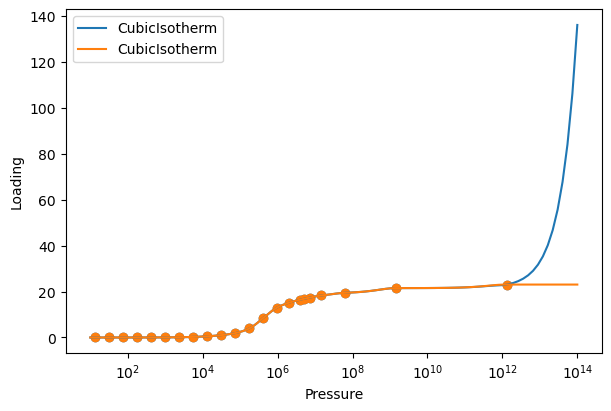

In [7]:
linear_extrap = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                              'CO2_fugacity[Pa]', extrap_method='linear')
model_extrap = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]',
                             'CO2_fugacity[Pa]', extrap_method='Langmuir')
pressures = np.logspace(1, 14, 100)
plot_isotherm([linear_extrap, model_extrap], xlogscale=True, pressures=pressures)

We can see that the linear extrapolation method can quickly result in significantly overestimating the loading at high pressures. The model extrapolation correctly captures saturation behavior. To demonstrate how the isotherm is built, let's create an isotherm using fugacity only up to 10 bar.

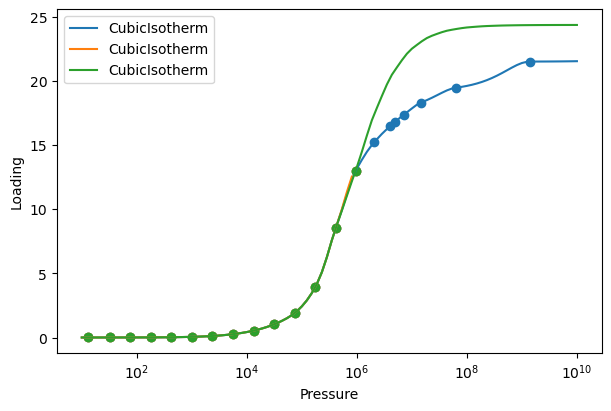

In [9]:
co2_cubic = CubicIsotherm(co2_pure, 'CO2_uptake_absolute[mol/kg]', 'CO2_fugacity[Pa]')
shortened_data = co2_pure[co2_pure['CO2_fugacity[Pa]'] <= 1e6]
shortened = CubicIsotherm(shortened_data, 'CO2_uptake_absolute[mol/kg]',
                            'CO2_fugacity[Pa]')
shortened_extrap = CubicIsotherm(shortened_data, 'CO2_uptake_absolute[mol/kg]',
                                'CO2_fugacity[Pa]', extrap_method='Langmuir')
pressures = np.logspace(1, 10, 100)
plot_isotherm([co2_cubic, shortened, shortened_extrap], xlogscale=True,
              pressures=pressures)

The original data is in blue and the extrapolated isotherm is in green. Although the model fit does not exactly match the saturation loading of the original data, it better captures the shape of the isotherm and produces more reasonable extrapolated values at high pressures. Like the normal CubicIsotherm, the extrapolated isotherm has a maximum pressure it can be evaluted to, which is by default 1e40. If you find that you need a higher maximum pressure, you can set extrap_p to a higher value when creating the isotherm.

Let's fit CubicIsotherms with Langmuir extrapolation for both CO2 and N2, and then use them for our calculations.

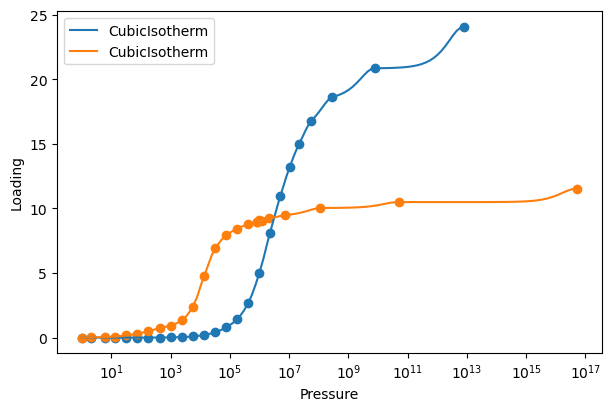

In [43]:
ch4_isotherm = CubicIsotherm(ch4_pure, 'CH4_uptake_absolute[mol/kg]',
                             'CH4_fugacity[Pa]', extrap_method='Langmuir')
propane_isotherm = CubicIsotherm(propane_pure, 'propane_uptake_absolute[mol/kg]',
                                 'propane_fugacity[Pa]', extrap_method='Langmuir')
plot_isotherm([ch4_isotherm, propane_isotherm], xlogscale=True)

# Ideal Adsorbed Solution Theory (IAST) Calculations
Now that we have our isotherms, we can use them to perform IAST calculations. The IAST method requires pure component isotherms to predict the adsorption of mixtures. We will use the isotherms we just created for CH4 and Propane to predict the binary adsorption of a mixture of these gases across a range of pressures and compositions.

In pyRAST, the IAST calculation is performed using the 'iast' function. The required inputs are the partial pressures of the components in the gas phase and a list of pure component isotherms. The function will return the predicted loadings of each component in the adsorbed phase. Let's see how this works in practice.

Note: We created the isotherms using fugacity, not pressure. The IAST function does not distinguish between pressure and fugacity. It is recommended to use fugacity for all calculations, if possible.

In [7]:
# Start with one calculation to demonstrate the function, and then we can loop through a
# range of conditions. Start with a 50/50 mixture at 10 bar total fugacity.

partial_fugacities = [5e5, 5e5]
isotherms = [ch4_isotherm, propane_isotherm]
loadings = iast(partial_fugacities, isotherms)
print(f"Predicted loadings: {loadings} mol/kg")

# With the verbose keyword, we can get more information about the calculation.
loadings = iast(partial_fugacities, isotherms, verbose=True)

Predicted loadings: [0.26670096 8.66066931] mol/kg
Performing IAST calculation for 2 components.
Component 0: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component 1: Partial Pressure = 500000.0, Isotherm Model = CubicIsotherm
Component  0
	p =  500000.0
	p^0 =  16736666.845876655
	Loading:  0.2667009612386947
	x =  0.029874526666770748
	Spreading pressure =  35.34045228357028
Component  1
	p =  500000.0
	p^0 =  515397.2488548959
	Loading:  8.660669310215496
	x =  0.9701254733332292
	Spreading pressure =  35.340452283570286


With the verbose keyword, we can see why extrapolation is often necessary for IAST calculations. IAST works by equating the spreading pressures of each component in the mixture, which for CO2 requires a P^0 of 5.36 bar, but for N2 requires a P^0 of 73.7 bar. Depending on the selectivity of the mixture, the P^0 of one component can be orders of magnitude higher than the other, which may require a pressure beyond the range of the data. Let's now loop through a range of pressures and compositions to see how IAST predictions match up with GCMC data.

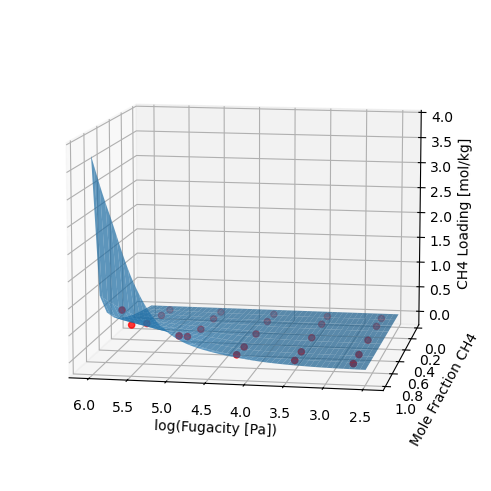

In [10]:
fugacity = np.logspace(2.5, 6, 100)
compositions = np.linspace(0.01, 0.99, 10)
load = np.zeros((len(compositions), len(fugacity)))
fig, ax = plt.subplots(subplot_kw={'projection': '3d'}, layout='constrained')
for i, x in enumerate(compositions):
    for j, f in enumerate(fugacity):
        partial_fugacities = [x * f, (1 - x) * f]
        loadings = iast(partial_fugacities, isotherms)
        load[i, j] = loadings[0]
X, Y = np.meshgrid(fugacity, compositions)
X = np.log10(X)
ax.plot_surface(X, Y, load, alpha=0.7)
ax.set_xlabel('log(Fugacity [Pa])')
ax.set_ylabel('Mole Fraction CH4')
ax.set_zlabel('CH4 Loading [mol/kg]')

# Plot original data
X = np.log10(ch4_propane_binary['CH4_fugacity[Pa]'] + ch4_propane_binary['propane_fugacity[Pa]'])
Y = ch4_propane_binary['y_CH4']
Z = ch4_propane_binary['CH4_uptake_absolute[mol/kg]']
ax.scatter(X, Y, Z, color='red', label='GCMC Data')
ax.view_init(elev=10, azim=100)

plt.show()

IAST overall captures the trends of the mixture adsorption, but there are some deviations from the GCMC data. We can see this more closely by focusing on a 50/50 mixture and plotting the selectivity of CO2 over N2. 

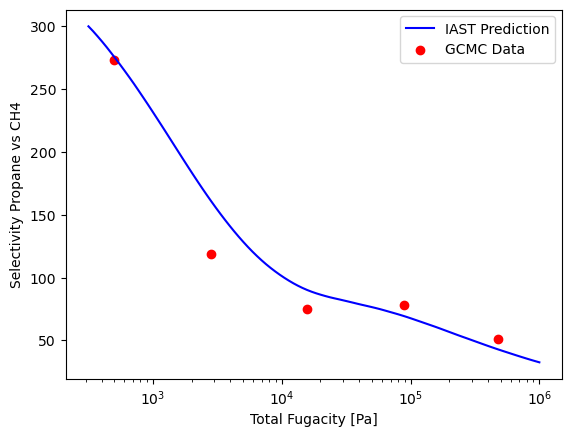

In [13]:
# 50/50 mixture selectivity
fugacities = np.logspace(2.5, 6, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [0.5 * f, 0.5 * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[1] / loadings[0])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity Propane vs CH4')

# Plot original data
data = ch4_propane_binary[ch4_propane_binary['y_CH4'] == 0.5]
selectivity = data['propane_uptake_absolute[mol/kg]'] / data['CH4_uptake_absolute[mol/kg]']
ax.scatter(data['propane_fugacity[Pa]'] + data['CH4_fugacity[Pa]'], selectivity,
           color='red', label='GCMC Data')
ax.legend()


plt.show()

Thus, IAST captures the trend of the data, but the error in selectivity can be >30%. Let's now fit an activity coefficient model to the binary data and see if we can improve our predictions.

# Activity Coefficient Fitting


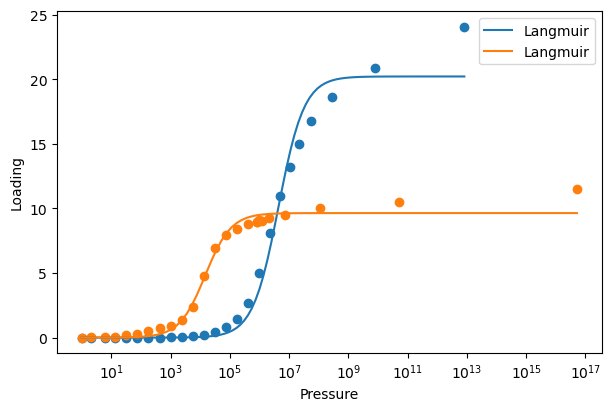

In [30]:
ch4_isotherm = ModelIsotherm(ch4_pure, 'CH4_uptake_absolute[mol/kg]',
                              'CH4_fugacity[Pa]', 'Langmuir')
propane_isotherm = ModelIsotherm(propane_pure, 'propane_uptake_absolute[mol/kg]',
                                  'propane_fugacity[Pa]', 'Langmuir')
isotherms = [ch4_isotherm, propane_isotherm]
plot_isotherm(isotherms, xlogscale=True)

In [51]:
partial_fug = np.array([ch4_propane_binary['CH4_fugacity[Pa]'].values,
                        ch4_propane_binary['propane_fugacity[Pa]'].values])
partial_fug = partial_fug.T
loadings = np.array([ch4_propane_binary['CH4_uptake_absolute[mol/kg]'].values,
            ch4_propane_binary['propane_uptake_absolute[mol/kg]'].values])
loadings = loadings.T
isotherms = [ch4_isotherm, propane_isotherm]
ac = ActivityCoefficient(partial_fug, loadings, isotherms, 'sMargules', param_tol=1e-8)
print(ac)

sMargules activity coefficient model with parameters: {'A': np.float64(-0.034511098485194874), 'C': np.float64(3.6183400171735283)}


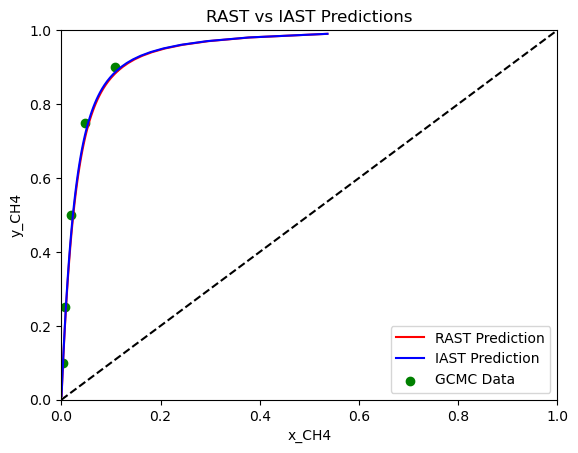

In [56]:
y_ch4 = np.linspace(0.01, 0.99, 100)
total_f = 5e5
x = np.zeros(len(y_ch4))
fig, ax = plt.subplots()

for i, y in enumerate(y_ch4):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = rast(partial_fugacities, isotherms, ac)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_ch4, label='RAST Prediction', color='red')

for i, y in enumerate(y_ch4):
    partial_fugacities = [y * total_f, (1 - y) * total_f]
    loadings = iast(partial_fugacities, isotherms)
    x[i] = loadings[0]/np.sum(loadings)
ax.plot(x, y_ch4, label='IAST Prediction', color='blue')

# Plot original data
data = ch4_propane_binary[ch4_propane_binary['total_pressure[Pa]'] == total_f]
x = data['CH4_uptake_absolute[mol/kg]']/(data['CH4_uptake_absolute[mol/kg]'] + data['propane_uptake_absolute[mol/kg]'])
y = data['y_CH4']
ax.scatter(x, y, color='green', label='GCMC Data')

ax.set_xlabel('x_CH4')
ax.set_ylabel('y_CH4')
ax.legend()
ax.set_title('RAST vs IAST Predictions')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axline((0, 0), slope=1, color='black', linestyle='--')
plt.show()



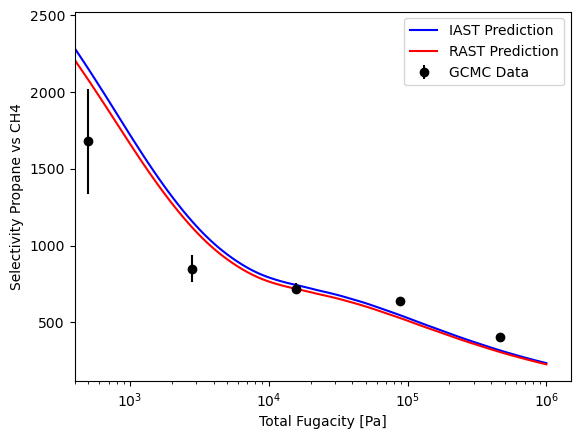

In [54]:
# 50/50 mixture selectivity
y = 0.1
fugacities = np.logspace(2.5, 6, 100)
selectivity = np.zeros(len(fugacities))
for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = iast(partial_fugacities, isotherms)
    selectivity[i] = (loadings[1] / loadings[0])
fig, ax = plt.subplots()
ax.plot(fugacities, selectivity, label='IAST Prediction', color='blue')
ax.set_xscale('log')
ax.set_xlabel('Total Fugacity [Pa]')
ax.set_ylabel('Selectivity Propane vs CH4')

for i, f in enumerate(fugacities):
    partial_fugacities = [y * f, (1 - y) * f]
    loadings = rast(partial_fugacities, isotherms, ac)
    selectivity[i] = (loadings[1] / loadings[0])
ax.plot(fugacities, selectivity, label='RAST Prediction', color='red')

# Plot original data
data = ch4_propane_binary[ch4_propane_binary['y_CH4'] == y]
error1 = (data['CH4_uptake_absolute_uncertainty[mol/kg]'] / data['CH4_uptake_absolute[mol/kg]'])**2
error2 = (data['propane_uptake_absolute_uncertainty[mol/kg]'] / data['propane_uptake_absolute[mol/kg]'])**2
selectivity = data['propane_uptake_absolute[mol/kg]'] / data['CH4_uptake_absolute[mol/kg]']
error = selectivity * np.sqrt(error1 + error2)
ax.errorbar(data['CH4_fugacity[Pa]'] + data['propane_fugacity[Pa]'], selectivity,
            yerr=error, fmt='o', color='black', label='GCMC Data')
ax.legend()
ax.set_xlim(4e2, 1.5e6)

plt.show()